# Логистическая регрессия
Разберем алгоритм логистической регрессии (logistic regression).

In [ ]:
# помимо стандартных библиотек мы также импортируем библиотеку warnings
# она позволит скрыть предупреждения об ошибках
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# кроме того, импортируем датасеты библиотеки sklearn
from sklearn import datasets
# а также функции для расчета метрики accuracy и построения матрицы ошибок
from sklearn.metrics import accuracy_score, confusion_matrix

# построенные нами модели мы будем сравнивать с результатом
# класса LogisticRegression библиотеки sklearn
from sklearn.linear_model import LogisticRegression

# среди прочего, мы построим модели полиномиальной логистической регрессии
from sklearn.preprocessing import PolynomialFeatures

## Бинарная логистическая регрессия
### Задача бинарной классификации
Вернемся к задаче кредитного скоринга, про которую мы говорили, когда
обсуждали принцип машинного обучения. Предположим, что мы собрали данные и
выявили зависимость возвращения кредита (ось y) от возраста заемщика (ось x).
![](https://drive.google.com/uc?export=view&id=1508oDUVfAPek5W13C24WcuVY211lsicB)
Как мы видим, в среднем более молодые заемщики реже возвращают кредит.
Возникает вопрос, с помощью какой модели можно описать эту зависимость?

Казалось бы, можно построить линейную регрессию таким образом, чтобы она
выдавала некоторое значение и, если это значение окажется ниже 0,5 — отнести
наблюдение к классу 0, если выше — к классу 1. Другими словами,
* если $ f_w(x) < 0{,}5 \rightarrow \hat{y} = 0; $ и
* если $ f_w(x) \geq 0{,}5 \rightarrow \hat{y} = 1. $

![](https://drive.google.com/uc?export=view&id=16nBr58MVR7WAtO9XwGsAwnyWZ-12Ey4N)

Однако, даже если предположить, что мы удачно провели линию регрессии (а на
графике выше мы действительно провели ее вполне удачно), и наша модель может
делать качественный прогноз, появление новых данных сместит эту границу, и, как
следствие, ничего не добавит, а только ухудшит точность модели.

![](https://drive.google.com/uc?export=view&id=1GWgnnBDCzAAtnB4AnvtU_b7Tw_zy6b08)

Теперь часть наблюдений, принадлежащих к классу 1, будет ошибочно отнесено моделью к классу 0.

Кроме этого, линейная регрессия по оси y выдает значения, сильно выходящие за
пределы интересующего нас интервала от нуля до единицы.


### Функция логистической регрессии

#### Сигмоида

Возможное решение упомянутых выше сложностей — пропустить значение
линейной регрессии через сигмоиду (sigmoid function), которая при любом
значении $x$ не выйдет из необходимого нам диапазона $0 \leq h(x) \leq 1. $
Напомню формулу и график сигмоиды.

$$ g(z) = \frac{1}{1+e^{-z}} $$

![](https://drive.google.com/uc?export=view&id=1yVrSNDkR0IMad_tkNrDqNb-90Tj053PQ)

Примечание. Обратите внимание, когда $z$ представляет собой большое
отрицательное число, знаменатель становится очень большим $ 1 + e^{-(-5)} \approx 149{,}413 $ и значение сигмоиды стремится к нулю; когда $z$ является большим положительным числом, знаменатель, а вместе с ним и все выражение стремятся к единице $ 1 + e^{-5} \approx 1{,}0067.$

Тогда мы можем построить линейную модель, значение которой будет подаваться в сигмоиду.

$$ z = X\theta \rightarrow h_{\theta}(x) = \frac{1}{1+e^{-(X\theta)}} $$

В этом смысле никакой ошибки в названии «логистическая регрессия» нет. Этот алгоритм решает задачу классификации через модель линейной регрессии.

Приведем код на Питоне.

In [ ]:
def h(x, thetas):
  z = np.dot(x, thetas)
  return 1.0 / (1 + np.exp(-z))

Теперь посмотрим, как интерпретировать коэффициенты.

#### Интерпретация коэффициентов
Для любого значения $x$ через $ h_{\theta}(x) $ мы будем получать вероятность от
0 до 1, что объект принадлежит к классу y = 1. Например, если класс 1 означает, что
заемщик вернул кредит, то $ h_{\theta}(x) = 0{,}8 $ говорит о том, что согласно
нашей модели с параметрами $\theta$, для данного заемщика $x$ вероятность
возвращения кредита состаляет 80 процентов.

В общем случае мы можем записать вероятность вот так.

$$ h_{\theta}(x) = P(y = 1 \mid x; \theta) $$

Это выражение можно прочитать, как вероятность принадлежности к классу 1 при
условии $x$ с параметрами $\theta$ (probability of y = 1 given x, parameterized by
$\theta$).

Поскольку, как мы помним, сумма вероятностей событий, образующих полную
группу, всегда равна единице, вероятность принадлежности к классу 0 будет равна

$$ P(y = 0 \mid x; \theta) = 1-P(y = 1 \mid x; \theta) $$

#### Решающая граница
Решающая граница (decision boundary) — это порог, который определяет, к какому
классу отнести то или иное наблюдение. Если выбрать порог на уровне 0,5, то все
что выше или равно этому порогу мы отнесем к классу 1, все что ниже — к классу
0.

$$ y = 1, h_{\theta}(x) \geq 0{,}5 $$

$$ y = 0, h_{\theta}(x) < 0{,}5 $$

Теперь обратите внимание на сигмоиду. Сигмоида $ g(z) $ принимает значения
больше 0,5, если $ z \geq 0 $, а так как $ z = X\theta $, то можно сказать, что $h_{\theta}(x) \geq 0{,}5$ и $ y = 1$, когда $ X\theta \geq 0 ;$ и соответственно
$h_{\theta}(x) \ < 0{,}5 $ и $ y = 0$, когда $ X\theta < 0 $.
#### Уравнение решающей границы
Предположим, что у нас есть два признака $x_1$ и $x_2$. Вместе они образуют так
называемое пространство ввода (input space), то есть все имеющиеся у нас
наблюдения. Мы можем представить это пространство на координатной плоскости,
дополнительно выделив цветом наблюдения, относящиеся к разным классам.

Кроме того, представим, что мы уже построили модель логистической регрессии, и
она провела для нас соответствующую границу между двумя классами.
![](https://drive.google.com/uc?export=view&id=16J4wWTbFb5FwEOSZ10LOzmzwMa5ZBGWP)

Возникает вопрос. Как, зная коэффициенты $\theta_0$, $\theta_1$ и $\theta_2$
модели, найти уравнение линии решающей границы? Для начала договоримся, что
уравнение решающией границы будет иметь вид $x_2 = mx_1 + c$, где $m$ —
наклон прямой, а $c$ — сдвиг.

Теперь вспомним, что модель с двумя признаками (до подачи в сигмоиду) имеет
вид

$$ z = \theta_0 + \theta_1 x_1 + \theta_2 x_2 $$

Также не забудем, что граница проходит там, где $ h_{\theta}(x) = 0{,}5 $, а значит
$z = 0.$ Значит,

$$ 0 = \theta_0 + \theta_1 x_1 + \theta_2 x_2 $$

Для того чтобы найти $с$ (то есть сдвиг линии решающей границы вдоль оси
$x_2$) приравняем $x_1$ к нулю и решим для $x_2$ (именно эта точка и будет
сдвигом c).

$$ 0 = \theta_0 + 0 + \theta_2 x_2 \rightarrow x_2 = -\frac{\theta_0}{\theta_2}
\rightarrow c = -\frac{\theta_0}{\theta_2} $$

Теперь займемся наклоном $m.$ Возьмем некоторую точку на линии решающей
границы с координатами $(x_1^a, x_2^a)$, $(x_1^b, x_2^b)$. Тогда наклон $m$
будет равен

$$ m = \frac{x_2^b-x_2^a}{x_1^b-x_1^a} $$

Так как эти точки расположены на решающей границе, то справедливо, что

$$ 0 = \theta_1x_1^b + \theta_2x_2^b + \theta_0-(\theta_1x_1^a + \theta_2x_2^a +
\theta_0) $$

$$ -\theta_2(x_2^b-x_2^a) = \theta_1(x_1^b-x_1^a) $$

А значит,

$$ \frac{x_2^b-x_2^a}{x_1^b-x_1^a} = -\frac{\theta_1}{\theta_2} \rightarrow m = -
\frac{\theta_1}{\theta_2} $$

#### Вычислительная устойчивость сигмоиды
При очень больших отрицательных или положительных значениях $z$ может
возникнуть переполнение памяти (overflow).

In [ ]:
# при очень больших отрицательных или положительных значениях z может возникнуть переполнение памяти (overflow)
# возьмем большое отрицательное значение
z = -999
1 / (1 + np.exp(-z))

/tmp/ipython-input-2908012810.py:4: RuntimeWarning: overflow encountered in exp
  1 / (1 + np.exp(-z))


np.float64(0.0)

Преодолеть это ограничение и добиться** вычислительной устойчивости** (numerical
stability) алгоритма можно с помощью следующего тождества.

$$ g(z) = \frac{1}{1+e^{-z}} = \frac{1}{1+e^{-z}} \cdot \frac{e^z}{e^z} = \frac{e^z}
{e^z(1+e^{-z})} = \frac {e^z}{e^z + 1} $$

Что интересно, первая часть тождества устойчива при очень больших
положительных значениях $z.$

In [ ]:
z = 999
1 / (1 + np.exp(-z))

np.float64(1.0)

При этом вторая стабильна при очень больших отрицательных значениях.

In [ ]:
z = -999
np.exp(z) / (np.exp(z) + 1)

np.float64(0.0)

Объединим обе части с помощью условия.

In [ ]:
def stable_sigmoid(z):
  if z >= 0:
      return 1 / (1 + np.exp(-z))
  else:
      return np.exp(z) / (np.exp(z) + 1)

Примечание. Мы не использовали более лаконичный код, например, функцию
**np.where()** , потому что эта функция прежде чем применить условие рассчитывает
оба сценария (в данном случае обе части тождества), а это ровно то, чего мы хотим
избежать, чтобы не возникло ошибки. Простое условие с if препятствует
выполнению той части кода, которая нам не нужна.

Можно также использовать **функцию expit()** библиотеки scipy.

In [ ]:
from scipy.special import expit
expit(999), expit(-999)

(np.float64(1.0), np.float64(0.0))

Остается написать линейную функцию и подать ее результат в сигмоиду.

In [ ]:
def h(x, thetas):
  z = np.dot(x, thetas)

  return np.array([stable_sigmoid(value) for value in z])

Протестируем код. Предположим, что в нашем датасете четыре наблюдения и три
коэффициента. Схематично расчеты будут выглядеть следующим образом.

![](https://drive.google.com/uc?export=view&id=1lmjCNPDIvQ9YbrXUmvp8Dfad3NpKRUpj)

Пропишем это на Питоне.

In [ ]:
# возьмем массив наблюдений 4 х 3 с числами от 1 до 12
x = np.arange(1, 13).reshape(4, 3)

# и вектор из трех коэффициентов
thetas = np.array([-3, 1, 1])

# подадим их в модель
h(x, thetas)

array([0.88079708, 0.26894142, 0.01798621, 0.00091105])

Модель работает корректно. Теперь обсудим, как ее обучать, то есть какую функцию потерь использовать для оптимизации параметров $\theta$.

### Logistic loss или функция кросс-энтропии
В модели логистической регрессии мы не можем использовать MSE. Дело в том, что если мы поместим результат сигмоиды (представляющей собою нелинейную функцию) в MSE, то на выходе получим невыпуклую функцию (non-convex), глобальный минимум которой довольно сложно найти.

![](https://drive.google.com/uc?export=view&id=1yzcw9rtOoSWrP1cxB4f3GTFVLfXJCwWD)

Вместо MSE мы будем использовать функцию логистической ошибки, которую
еще называют функцией бинарной кросс-энтропии (log loss, binary cross-entropy
loss).
### График и формула функции логистической ошибки
Вначале посмотрим на нее на графике.



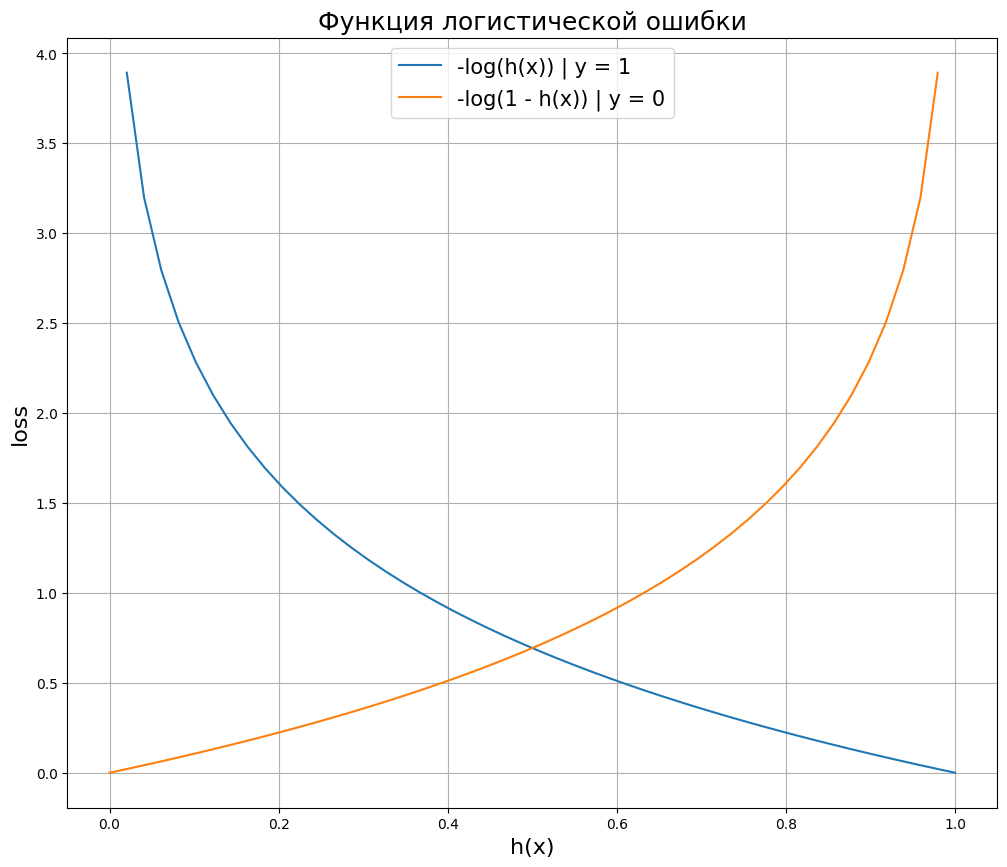

In [ ]:
# уберем предупреждения о делении на ноль (нам это нужно для качественного графика)
with warnings.catch_warnings():
  warnings.simplefilter('ignore')

  plt.figure(figsize = (12, 10))

  x_vals = np.linspace(0, 1)

  plt.plot(x_vals, -np.log(x_vals), label = '-log(h(x)) | y = 1')
  plt.plot(x_vals, -np.log(1 - x_vals), label = '-log(1 - h(x)) | y = 0')
  plt.xlabel('h(x)', fontsize = 16)
  plt.ylabel('loss', fontsize = 16)
  plt.title('Функция логистической ошибки', fontsize = 18)

  plt.legend(loc = 'upper center', prop = {'size': 15})
  plt.grid()
  plt.show()


Разберемся, как она работает. Наша модель $h_{\theta}(x)$ может выдавать
*вероятность* от 0 до 1, фактические значения $y$ только 0 и 1.

**Сценарий 1.** Предположим, что для конкретного заемщика в обучающем датасете
истинное значение/ целевой класс записан как 1 (то есть заемщик вернул кредит).
Тогда «срабатывает» синяя ветвь графика и ошибка измеряется по ней.
Соответственно, чем ближе выдаваемая моделью вероятность к единице, тем
меньше ошибка.

$$ -\log(P(y = 1 \mid x; \theta)) = -\log(h_{\theta}(x)), y = 1 $$

**Сценарий 2.** Заемщик не вернул кредит, и его целевая переменная записана как 0.
Тогда срабатывает оранжевая ветвь. Ошибка модели будет минимальна при
значениях, близких к нулю.

$$ -\log(1-P(y = 1 \mid x; \theta)) = -\log(1-h_{\theta}(x)), y = 0 $$

Добавлю, что минус логарифм в данном случае очень удачно отвечает нашему
желанию иметь нулевую ошибку при правильном прогнозе и наказать алгоритм
высокой ошибкой (асимптотически стремящейся к бесконечности) в случае
неправильного прогноза.

В итоге нам нужно будет найти сумму вероятностей принадлежности к классу 1
для сценария 1 и сценария 2.

$$ J(\theta) = \begin{cases} -\log(h_{\theta}(x)) & y=1 \\ -\log(1-h_{\theta}(x)) & y=0
\end{cases} $$

Однако, для каждого наблюдения нам нужно учитывать только одну из
вероятностей (либо $y=1$, либо $y=0$). Как нам переключаться между ними? На
самом деле очень просто.

В качестве переключателя можно использовать целевую переменную. В
частности, умножим левую часть функции на $y$, а правую на $1-y$. Тогда, если
речь идет о классе 1, первая часть умножится на единицу, вторая на ноль и
исчезнет. Если речь идет о классе 0, произойдет обратное, исчезнет левая часть, а
правая останется. Получается

$$ J(\theta) = -\frac{1}{n} \sum y \cdot log(h_{\theta}(x)) + (1-y) \cdot log(1-h_{\theta}
(x)) $$

Рассмотрим ее работу на учебном примере.

#### Расчет логистической ошибки
Предположим, мы построили модель и для каждого наблюдения получили
некоторый прогноз (вероятность).

In [ ]:
# предположим, мы построили модель
# выведем результат работы модели (вероятности) y_pred и целевую переменную y
output = pd.DataFrame({
    'y'        :[1, 1, 1, 0, 0, 1, 1, 0],
    'y_pred'   :[0.93, 0.81, 0.78, 0.43, 0.54, 0.49, 0.22, 0.1]
})

output

,y,y_pred
0,1,0.93
1,1,0.81
2,1,0.78
3,0,0.43
4,0,0.54
5,1,0.49
6,1,0.22
7,0,0.10


Найдем вероятность принадлежности к классу 1.

In [ ]:
# найдем вероятность принадлежности к классу 1
# оставим вероятность, если y = 1, и вычтем вероятность из единицы, если y = 0
output['y=1 prob'] = np.where(output['y'] == 0, 1 - output['y_pred'], output['y_pred'])
output

,y,y_pred,y=1 prob
0,1,0.93,0.93
1,1,0.81,0.81
2,1,0.78,0.78
3,0,0.43,0.57
4,0,0.54,0.46
5,1,0.49,0.49
6,1,0.22,0.22
7,0,0.10,0.90


Возьмем отрицательный логарифм из каждой вероятности.

In [ ]:
# возьмем отрицательный логарифм из каждой вероятности
output['-log'] = -np.log(output['y=1 prob'])
output

,y,y_pred,y=1 prob,-log
0,1,0.93,0.93,0.072571
1,1,0.81,0.81,0.210721
2,1,0.78,0.78,0.248461
3,0,0.43,0.57,0.562119
4,0,0.54,0.46,0.776529
5,1,0.49,0.49,0.713350
6,1,0.22,0.22,1.514128
7,0,0.10,0.90,0.105361


Выведем каждое из получившихся значений на графике.

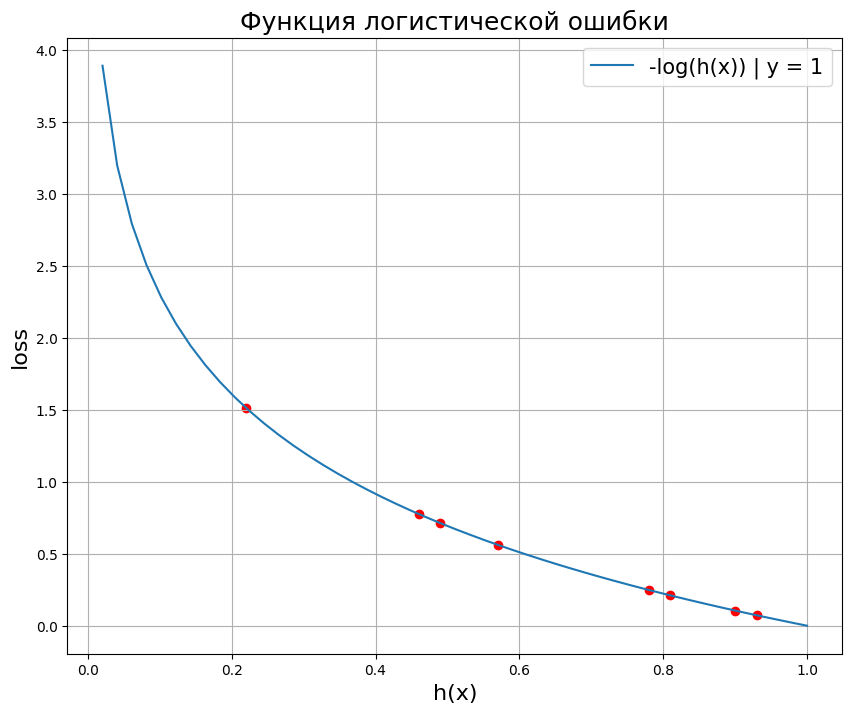

In [ ]:
with warnings.catch_warnings():
  warnings.simplefilter('ignore')

  plt.figure(figsize = (10, 8))

  # создадим точки по оси x в промежутке от 0 до 1
  x_vals = np.linspace(0, 1)

  # выведем кривую функции логистической ошибки
  plt.plot(x_vals, -np.log(x_vals), label = '-log(h(x)) | y = 1')

  # выведем каждое из значений отрицательного логарифма
  plt.scatter(output['y=1 prob'], output['-log'], color = 'r')

  # зададим заголовок, подписи к осям, легенду и сетку
  plt.xlabel('h(x)', fontsize = 16)
  plt.ylabel('loss', fontsize = 16)
  plt.title('Функция логистической ошибки', fontsize = 18)
  plt.legend(loc = 'upper right', prop = {'size': 15})
  plt.grid()

  plt.show()

Как мы видим, так как мы всегда выражаем вероятность принадлежности к классу
1, графически нам будет достаточно одной ветви. Остается сложить результаты и
разделить на количество наблюдений.

In [ ]:
# сложим значения и разделим на количество наблюдений
output['-log'].mean()

np.float64(0.525404865908324)

#### Окончательный вариант

Напишем функцию логистической ошибки, которую будем использовать в нашем
алгоритме.

In [ ]:
# напишем функцию логистической ошибки для нашего алгоритма
def objective(y, y_pred):

  # рассчитаем функцию потерь для y = 1, добавив 1e-9, чтобы избежать ошибки при log(0)
  y_one_loss = y * np.log(y_pred + 1e-9)

  # также рассчитаем функцию потерь для y = 0
  y_zero_loss = (1 - y) * np.log(1 - y_pred + 1e-9)

  # сложим и разделим на количество наблюдений
  return -np.mean(y_zero_loss + y_one_loss)

Проверим ее работу на учебных данных.

In [ ]:
# проверим ее работу на учебных данных
objective(output['y'], output['y_pred'])

np.float64(0.5254048640061278)

$$\require{cancel}$$
Теперь займемся поиском производной.
### Производная функции логистической ошибки
Запишем функцию логистической ошибки $J(\theta)$ в векторизованной форме

$$ J(\theta) = -\frac{1}{n} [y \cdot \log(h(z) + (1-y) \cdot log(1-h(z))] $$

где $h$ — это сигмоида $\frac{1}{1+e^{-z}}$, а $z$ — линейная функция $X\theta$.
Нам нужно найти ее градиент

$$ \nabla_{\theta} J \left( -\frac{1}{n} [y \cdot \log(h(z) + (1-y) \cdot log(1-h(z))] \right)
$$

Другими словами, по правилу производной сложной функции для каждого
признака $\theta_j$ нужно взять частные производные следующих функций

$$ \frac{\partial J}{\partial \theta_j} = \frac{\partial J}{\partial h} \cdot \frac{\partial h}
{\partial z} \cdot \frac{\partial z}{\partial \theta_j} $$

#### Производная логарифмической функции
Начнем с производной логарифмической функции. Поскольку

$$ \frac{d}{d x} ln(x) = \frac{1}{x} $$

и помня, что $x$ и $y$ — это константы, найдем первую производную. Временно
положим $h(z) = h.$

$$ \frac{\partial J}{\partial h} \left[ y \cdot log(h) + (1-y) \cdot log(1-h) \right] $$

$$ = y \cdot \frac{\partial J}{\partial h} [log(h)] + (1-y) \cdot \frac{\partial J}{\partial h}
[log(1-h)] $$

$$ = y \cdot \frac{1}{h} + (1-y) \cdot \frac{1}{(1-h)} \cdot \frac{\partial J}{\partial h}
[1-h] $$

$$ = \frac{y}{h} + \frac{1-y}{1-h} \cdot (0-1) $$

$$ = \frac{y}{h} + \frac{y-1}{1-h} = \frac{ y(1-h)+h(y-1) }{h(1-h)} $$

$$ = \frac{y-\cancel{yh}+\cancel{hy}-h}{h(1-h)} = \frac{y-h}{h(1-h)} $$

Вернув $h = h(z),$ получим

$$ \frac{\partial J}{\partial h} = \frac{y-h(z)}{h(z)(1-h(z))} $$

Теперь займемся производной сигмоиды.

#### Производная сигмоиды
Заметим, что

$$ \frac{d}{dx} e^x = e^x $$

Перепишем выражение

$$ \frac{\partial h}{\partial z} \left[ \frac{1}{1+e^{-z}} \right] = \frac{\partial h}{\partial
z} \left[ (1+e^{-z})^{-1} \right] $$

По правилу производной сложной функции

$$ = -(1+e^{-z})^{-2} \cdot (-e^{-z}) = \frac{e^{-z}}{(1+e^{-z})^2} $$
$$ = \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}} = \frac{1}{1+e^{-z}} \cdot
\frac{(1+e^{-z})-1}{1+e^{-z}} $$

$$ = \frac{1}{1+e^{-z}} \cdot \left( \frac{1+e^{-z}}{1+e^{-z}}-\frac{1}{1+e^{-z}}
\right) $$

$$ = \frac{1}{1+e^{-z}} \cdot \left( 1-\frac{1}{1+e^{-z}} \right) $$

В терминах предложенной выше нотации получается

$$ \frac{\partial h}{\partial z} = h(z)(1-h(z)) $$
#### Производная линейной функции
Наконец найдем производную линейной функции.

$$ \frac{\partial z}{\partial \theta} [X \theta] = X $$
#### Градиент
Перемножим частные производные и найдем градиент.

$$ \nabla_{\theta} J \left( -\frac{1}{n} [y \cdot \log(h(z) + (1-y) \cdot log(1-h(z))] \right)
$$

$$ = -\frac{1}{n} \left[ \frac{\partial J}{\partial h} \cdot \frac{\partial h}{\partial z} \cdot
\frac{\partial z}{\partial \theta_j} \right] $$

$$ = -\frac{1}{n} \left[ \frac{y-h(z)}{h(z)(1-h(z))} \cdot h(z)(1-h(z)) \cdot X \right] $$

$$ = -\frac{1}{n} [(y-h(z)) \cdot X] = [X^\top (h(z)-y)] \times \frac{1}{n} $$

Поскольку $z = X\theta,$

$$ \nabla_{\theta} J = [X^\top (h(X\theta)-y)] \times \frac{1}{n} $$

Замечу, что хотя результат похож на градиент функции линейной регрессии,
на самом деле это разные функции, $h$ в данном случае сигмоида.

Схематично для четырех наблюдений и трех коэффициентов нахождение градиента
будет выглядеть следующим образом.

![](https://drive.google.com/uc?export=view&id=1Os-yvNwBE9rEbDBuaIOY3DbiKQTOl_ZN)

Объявим соответствующую функцию.

In [ ]:
# объявим градиент функции логистической ошибки
def gradient(x, y, y_pred, n):
  return np.dot(x.T, (y_pred - y)) * (1/n)

Напомню, что прогнозные значения (y_pred) мы получаем с помощью написанной
ранее функции `h(x, thetas)`.

### Подготовка данных

В качестве примера возьмем встроенный в sklearn датасет, в котором нам
предлагается определить класс вина по его характеристикам.

In [ ]:
# импортируем датасет о вине из модуля datasets
data = datasets.load_wine()

# превратим его в датафрейм
df = pd.DataFrame(data.data, columns = data.feature_names)

# добавим целевую переменную
df['target'] = data.target

# посмотрим на первые три строки
df.head(3)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0


#### Целевая переменная

Посмотрим на количество наблюдений и признаков (размерность матрицы), а также
на уникальные значения (классы) в целевой переменной.

In [ ]:
# выведем размерность матрицы и уникальные значения в целевой переменной
df.shape, np.unique(df.target)

((178, 14), array([0, 1, 2]))

Как мы видим, у нас три класса, а должно быть два, потому что пока что мы
создаем алгоритм бинарной классификации. Отфильтруем значения так, чтобы
осталось только два класса.

In [ ]:
# применим маску датафрейма и удалим класс 2
df = df[df.target != 2]

# посмотрим на результат
df.shape, df.target.unique()

((130, 14), array([0, 1]))

#### Отбор признаков

Наша целевая переменная выражена бинарной категорией или, как еще говорят,
находится на дихотомической шкале. В этом случае применять коэффициент
корреляции Пирсона не стоит и можно использовать точечно-бисериальную
корреляцию. Рассчитаем корреляцию признаков и целевой переменной нашего
датасета.

Точечно-бисериальная корреляция

In [ ]:
# импортируем модуль stats из библиотеки scipy
from scipy import stats

# создадим два списка, один для названий признаков, второй для корреляций
columns, correlations = [], []

# пройдемся по всем столбцам датафрейма кроме целевой переменной
for col in df.drop('target', axis = 1).columns:
  # поместим название признака в список columns
  columns.append(col)
  # рассчитаем корреляцию этого признака с целевой переменной
  # и поместим результат в список корреляций
  correlations.append(stats.pointbiserialr(df[col], df['target'])[0])

# создадим датафрейм на основе заполненных списков
# и применим градиентную цветовую схему
pd.DataFrame({'column': columns, 'correlation': correlations}).style.background_gradient()

,column,correlation
0,alcohol,-0.824399
1,malic_acid,-0.044302
2,ash,-0.354548
3,alcalinity_of_ash,0.470437
4,magnesium,-0.383085
5,total_phenols,-0.532692
6,flavanoids,-0.610730
7,nonflavanoid_phenols,0.337489
8,proanthocyanins,-0.249205
9,color_intensity,-0.750613


Наиболее коррелирующим с целевой переменной признаком является пролин
(proline). Визуально оценим насколько сильно отличается этот показатель для
классов вина 0 и 1.

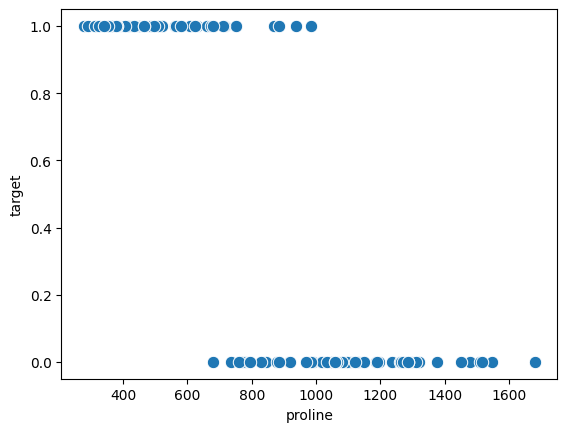

In [ ]:
# на точечной диаграмме выведем пролин по оси x, а класс вина по оси y
sns.scatterplot(x = df.proline, y = df.target, s = 80);

Теперь посмотрим на зависимость двух признаков (спирт и пролин) от целевой
переменной.

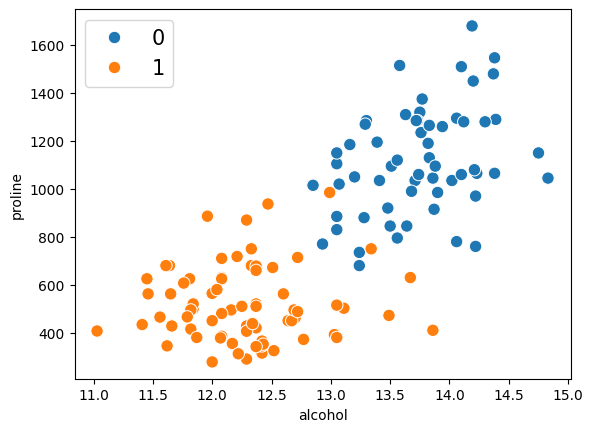

In [ ]:
# на точечной диаграмме по осям x и y выведем признаки,
# с помощью параметра hue разделим соответствующие классы целевой переменной
sns.scatterplot(x = df.alcohol, y = df.proline, hue = df.target, s = 80)
# добавим легенду, зададим ее расположение и размер
plt.legend(loc = 'upper left', prop = {'size': 15})
# выведем результат
plt.show()

В целом можно сказать, что классы линейно разделимы (другими словами, мы
можем провести прямую линию между ними). Поместим признаки в переменную X,
а целевую переменную в y.

In [ ]:
# поместим признаки в переменную X, а целевую переменную в y
X = df[['alcohol', 'proline']]
y = df['target']

In [ ]:
# посмотрим на количество наблюдений в каждом из классов
df.target.value_counts()

,count
target,
1,71
0,59


#### Масштабирование признаков
Как и в случае с линейной регрессией, для алгоритма логистической регрессии
важно, чтобы признаки были приведены к одному масштабу. Для этого используем
стандартизацию.

In [ ]:
# выполним стандартизацию
# т.е. приведем данные к нулевому среднему и единичному СКО
X = (X - X.mean()) / X.std()
X.head()

,alcohol,proline
0,1.446858,0.779851
1,0.287952,0.737300
2,0.242946,1.120264
3,1.604379,1.957113
4,0.332958,-0.156284


Проверим результат.

In [ ]:
# проверим результат
X.alcohol.mean(), X.alcohol.std(), X.proline.mean(), X.proline.std()

(np.float64(6.777484556480956e-15), 0.9999999999999997, np.float64(0.0), 1.0)

Теперь мы готовы к созданию и обучению модели.

### Обучение модели
Вначале объявим уже знакомую нам функцию, которая добавит в датафрейм
столбец под названием x0, заполненный единицами.

In [ ]:
# объявим функцию, которая будет добавлять столбец под названием x0, заполненный единицами
def add_ones(x):
  # важно! метод .insert() изменяет исходный датафрейм
  return x.insert(0,'x0', np.ones(x.shape[0]))

Применим ее к нашему датафрейму с признаками.

In [ ]:
# добавим столбец с единицами
add_ones(X)

# и посмотрим на результат
X.head()

,x0,alcohol,proline
0,1.0,1.446858,0.779851
1,1.0,0.287952,0.737300
2,1.0,0.242946,1.120264
3,1.0,1.604379,1.957113
4,1.0,0.332958,-0.156284


Создадим вектор начальных весов (он будет состоять из нулей), а также
переменную n, в которой будет храниться количество наблюдений.

In [ ]:
# создадим вектор начальных весов (он будет состоять из нулей),
# а также переменную n, в которой будет храниться количество наблюдений
thetas, n = np.zeros(X.shape[1]), X.shape[0]
thetas, n

(array([0., 0., 0.]), 130)

Кроме того, создадим список, в который будем записывать размер ошибки функции
потерь.

In [ ]:
# создадим список, в который будем записывать размер ошибки функции потерь
loss_history = []

Теперь выполним основную работу по минимизации функции потерь и поиску
оптимальных весов (выполнение кода ниже у меня заняло около 30 секунд).

In [ ]:
# в цикле из 20000 итераций
for i in range(20000):
  # рассчитаем прогнозное значение с текущими весами
  y_pred = h(X, thetas)
  # посчитаем уровень ошибки при текущем прогнозе
  loss_history.append(objective(y, y_pred))
  # рассчитаем градиент
  grad = gradient(X, y, y_pred, n)
  # используем градиент для улучшения весов модели
  # коэффициент скорости обучения будет равен 0,001
  thetas = thetas - 0.001 * grad

Посмотрим на получившиеся веса и финальный уровень ошибки.

In [ ]:
# посмотрим на получившиеся веса и финальный уровень ошибки
thetas, loss_history[-1]

(array([ 0.23234188, -1.73394252, -1.89350543]),
 np.float64(0.12282503517421262))

Модель обучена. Теперь мы можем сделать прогноз и оценить результат.

### Прогноз и оценка качества

#### Прогноз модели

Объявим функцию predict(), которая будет предсказывать к какому классу
относится то или иное наблюдение. От функции h(x, thetas) эта функция будет
отличаться тем, что выдаст не только вероятность принадлежности к тому или
иному классу, но и непосредственно сам предполагаемый класс (0 или 1).

In [ ]:
# объявим функцию для предсказания класса
def predict(x, thetas):
  # найдем значение линейной функции
  z = np.dot(x, thetas)
  # проведем его через устойчивую сигмоиду
  probs = np.array([stable_sigmoid(value) for value in z])
  # если вероятность больше или равна 0,5 - отнесем наблюдение к классу 1,
  # в противном случае к классу 0
  # дополнительно выведем значение вероятности
  return np.where(probs >= 0.5, 1, 0), probs

Вызовем функцию predict() и запишем прогноз класса и вероятность
принадлежности к этому классу в переменные y_pred и probs соответственно.

In [ ]:
# запишем прогноз класса и вероятность этого прогноза в переменные y_pred и probs
y_pred, probs = predict(X, thetas)

# посмотрим на прогноз и вероятность для первого наблюдения
y_pred[0], probs[0]

(np.int64(0), np.float64(0.022908352078195634))

Здесь важно напомнить, что вероятность, близкая к нулю, говорит о
пренадлжености к классу 0. В качестве упражнения выведите класс
последнего наблюдения и соответствующую вероятность.

#### Метрика accuracy и матрица ошибок

Оценим результат с помощью метрики accuracy и матрицы ошибок.

In [ ]:
# оценим результат с помощью метрики accuracy
accuracy_score(y, y_pred)

0.9615384615384616

In [ ]:
# а также построим на матрицу ошибок
# столбцами будут прогнозные значения (Forecast),
# строками - фактические (Actual)
pd.DataFrame(confusion_matrix(y, y_pred),
             columns = ['Forecast 0', 'Forecast 1'],
             index = ['Actual 0', 'Actual 1'])

,Forecast 0,Forecast 1
Actual 0,57,2
Actual 1,3,68


Как мы видим, алгоритм ошибся пять раз. Дважды он посчитал, что наблюдение
относится к классу 1, хотя на самом деле это был класс 0, и трижды, наоборот,
неверно отнес класс 1 к классу 0.

#### Решающая граница

Выше мы уже вывели уравнение решающей границы. Воспользуемся им, чтобы
визуально оценить насколько удачно классификатор справился с поставленной
задачей.

In [ ]:
# рассчитаем сдвиг (c) и наклон (m) линии границы
c, m = -thetas[0]/thetas[2], -thetas[1]/thetas[2]
c, m

(np.float64(0.12270462635312818), np.float64(-0.915731474695505))

In [ ]:
# найдем минимальное и максимальное значения для спирта (ось x)
xmin, xmax = min(X['alcohol']), max(X['alcohol'])
# найдем минимальное и максимальное значения для пролина (ось y)
ymin, ymax = min(X['proline']), max(X['proline'])

# запишем значения оси x в переменную xd
xd = np.array([xmin, xmax])
xd

array([-2.15362589,  2.12194856])

In [ ]:
# подставим эти значения, а также значения сдвига и наклона в уравнение линии
yd = m * xd + c

# в результате мы получим координаты двух точек, через которые проходит линия границы
(xd[0], yd[0]), (xd[1], yd[1])

((np.float64(-2.1536258890738242), np.float64(2.0948476376971192)),
 (np.float64(2.1219485561396643), np.float64(-1.820430454188644)))

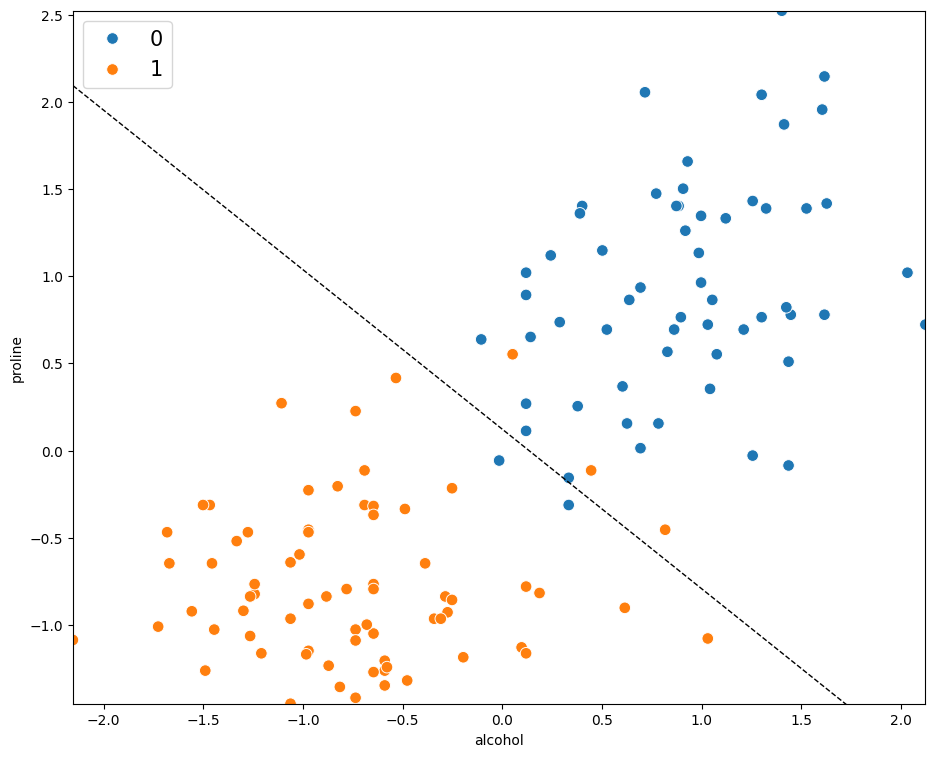

In [ ]:
# зададим размер графика
plt.figure(figsize = (11, 9))

# построим пунктирную линию по двум точкам, найденным выше
plt.plot(xd, yd, 'k', lw = 1, ls = '--')

# дополнительно отобразим наши данные,
sns.scatterplot(x = X['alcohol'], y = X['proline'], hue = y, s = 70)

# которые снова снабдим легендой
plt.legend(loc = 'upper left', prop = {'size': 15})

# минимальные и максимальные значения по обеим осям будут границами графика
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

# по желанию, разделенные границей половинки можно закрасить
# tab: означает, что цвета берутся из палитры Tableau
# plt.fill_between(xd, yd, ymin, color='tab:blue', alpha = 0.2)
# plt.fill_between(xd, yd, ymax, color='tab:orange', alpha = 0.2)

# а также добавить обозначения переменных в качестве подписей к осям
# plt.xlabel('x_1')
# plt.ylabel('x_2')

plt.show()

На графике хорошо видны те пять значений, в которых ошибся наш классификатор.

### Написание класса

Остается написать класс бинарной логистической регрессии.

In [ ]:
class LogReg():

  # в методе .__init__() объявим переменные для весов и уровня ошибки
  def __init__(self):
    self.thetas = None
    self.loss_history = []

  # метод .fit() необходим для обучения модели
  # этому методу мы передадим признаки и целевую переменную
  # кроме того, мы зададим значения по умолчанию
  # для количества итераций и скорости обучения
  def fit(self, x, y, iter = 20000, learning_rate = 0.001):

    # метод создаст "правильные" копии датафрейма
    x, y = x.copy(), y.copy()

    # добавит столбец из единиц
    self.add_ones(x)

    # инициализирует веса и запишет в переменную n количество наблюдений
    thetas, n = np.zeros(x.shape[1]), x.shape[0]

    # создадим список для записи уровня ошибки
    loss_history = []

    # в цикле, равном количеству итераций
    for i in range(iter):
      # метод сделает прогноз с текущими весами
      y_pred = self.h(x, thetas)
      # найдет и запишет уровень ошибки
      loss_history.append(self.objective(y, y_pred))
      # рассчитает градиент
      grad = self.gradient(x, y, y_pred, n)
      # и обновит веса
      thetas -= learning_rate * grad

      # метод выдаст веса и список с историей ошибок
      self.thetas = thetas
      self.loss_history = loss_history

  # метод .predict() делает прогноз с помощью обученной модели
  def predict(self, x):

    # метод создаст "правильную" копию модели
    x = x.copy()
    # добавит столбец из единиц
    self.add_ones(x)
    # рассчитает значения линейной функции
    z = np.dot(x, self.thetas)
    # передаст эти значения в сигмоиду
    probs = np.array([self.stable_sigmoid(value) for value in z])
    # выдаст принадлежность к определенному классу и соответствующую вероятность
    return np.where(probs >= 0.5, 1, 0), probs

  # ниже приводятся служебные методы, смысл которых был разобран ранее
  def add_ones(self, x):
    return x.insert(0,'x0', np.ones(x.shape[0]))

  def h(self, x, thetas):
    z = np.dot(x, thetas)
    return np.array([self.stable_sigmoid(value) for value in z])

  def objective(self, y, y_pred):
    y_one_loss = y * np.log(y_pred + 1e-9)
    y_zero_loss = (1 - y) * np.log(1 - y_pred + 1e-9)
    return -np.mean(y_zero_loss + y_one_loss)

  def gradient(self, x, y, y_pred, n):
    return np.dot(x.T, (y_pred - y)) / n

  def stable_sigmoid(self, z):
    if z >= 0:
        return 1 / (1 + np.exp(-z))
    else:
        return np.exp(z) / (np.exp(z) + 1)

Проверим работу написанного нами класса. Вначале подготовим данные и обучим
модель.

In [ ]:
# проверим работу написанного нами класса
# поместим признаки и целевую переменную в X и y
X = df[['alcohol', 'proline']]
y = df['target']

# приведем признаки к одному масштабу
X = (X - X.mean())/X.std()

# создадим объект класса LogReg
model = LogReg()

# и обучим модель
model.fit(X, y)

# посмотрим на атрибуты весов и финального уровня ошибки
model.thetas, model.loss_history[-1]

(array([ 0.23234188, -1.73394252, -1.89350543]),
 np.float64(0.12282503517421262))

Затем сделаем прогноз и оценим качество модели.

In [ ]:
# сделаем прогноз
y_pred, probs = model.predict(X)

# и посмотрим на класс первого наблюдения и вероятность
y_pred[0], probs[0]

(np.int64(0), np.float64(0.022908352078195634))

In [ ]:
# рассчитаем accuracy
accuracy_score(y, y_pred)

0.9615384615384616

In [ ]:
# создадим матрицу ошибок
pd.DataFrame(confusion_matrix(y, y_pred),
             columns = ['Forecast 0', 'Forecast 1'],
             index = ['Actual 0', 'Actual 1'])

,Forecast 0,Forecast 1
Actual 0,57,2
Actual 1,3,68


Модель показала точно такой же результат. Методы класса LogReg работают.
Теперь давайте сравним работу нашего класса с классом LogisticRegression
библиотеки sklearn.

### Сравнение с Sklearn

Обучение модели

Вначале обучим модель.

In [ ]:
# подготовим данные
X = df[['alcohol', 'proline']]
y = df['target']

X = (X - X.mean())/X.std()

# создадим объект класса LogisticRegression и запишем его в переменную model
model = LogisticRegression()

# обучим модель
model.fit(X, y)

# посмотрим на получившиеся веса модели
model.intercept_, model.coef_

(array([0.30840839]), array([[-2.09370706, -2.45841417]]))

#### Прогноз

Теперь необходимо сделать прогноз и найти соответствующие вероятности. В
классе **LogisticRegression** библиотеки sklearn **метод .predict()** отвечает за
предсказание принадлежности к определенному классу, а **метод .predict_proba()**
отвечает за вероятность такого прогноза.

In [ ]:
# выполним предсказание класса
y_pred = model.predict(X)

# и найдем вероятности
probs = model.predict_proba(X)

# посмотрим на класс и вероятность первого наблюдения
y_pred[0], probs[0]

(np.int64(0), array([0.99041652, 0.00958348]))

Модель предсказала для первого наблюдения класс 0. При этом, обратите
внимание, что метод **.predict_proba()** для каждого наблюдения выдает две
вероятности, первая — это вероятность принадлежности к классу 0, вторая — к
классу 1.

####Оценка качества

Рассчитаем метрику accuracy.

In [ ]:
# найдем accuracy
accuracy_score(y, y_pred)

0.9615384615384616

И построим матрицу ошибок.

In [ ]:
# и построим матрицу ошибок
pd.DataFrame(confusion_matrix(y, y_pred),
             columns = ['Forecast 0', 'Forecast 1'],
             index = ['Actual 0', 'Actual 1'])

,Forecast 0,Forecast 1
Actual 0,57,2
Actual 1,3,68


Как мы видим, хотя веса модели и предсказанные вероятности немного отличаются,
ее точность осталась неизменной.

#### Решающая граница

Построим решающую границу.

In [ ]:
# найдем сдвиг и наклон для уравнения решающей границы
c, m = -model.intercept_ / model.coef_[0][1], -model.coef_[0][0] / model.coef_[0][1]
c, m

(array([0.12545014]), np.float64(-0.8516494420718931))

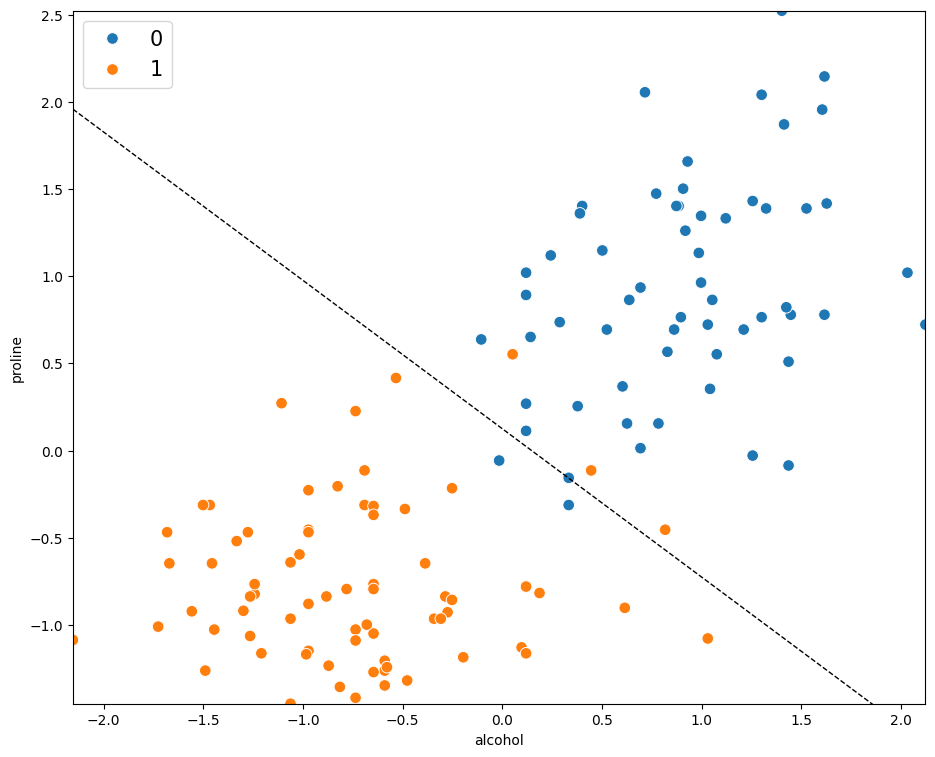

In [ ]:
# посмотрим на линию решающей границы
plt.figure(figsize = (11, 9))

xmin, xmax = min(X['alcohol']), max(X['alcohol'])
ymin, ymax = min(X['proline']), max(X['proline'])
xd = np.array([xmin, xmax])
yd = m*xd + c
plt.plot(xd, yd, 'k', lw=1, ls='--')
sns.scatterplot(x = X['alcohol'], y = X['proline'], hue = y, s = 70)
plt.legend(loc = 'upper left', prop = {'size': 15})

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)

plt.show()

### Бинарная полиномиальная регрессия

Идея **бинарной полиномиальной логистической регрессии** (binary polynomial
logistic regression) заключается в том, чтобы использовать полином внутри
сигмоиды и соответственно создать нелинейную границу между двумя классами.

![](https://drive.google.com/uc?export=view&id=1WnATcV9-3IucPZ1PTRcESA3ilJLwydsP)



#### Полиномиальные признаки

Уравнение полинома на основе двух признаков будет выглядеть следующим
образом

$$ y = \theta_{0}x_0 + \theta_{1}x_1 + \theta_{2}x_2 + \theta_{3} x_1^2 + \theta_{4}
x_1x_2 + \theta_{5} x_2^2 $$

Реализуем этот алгоритм на практике и посмотрим, улучшатся ли результаты.
Вначале, подготовим и масштабируем данные.

In [ ]:
# подготовим и
X = df[['alcohol', 'proline']]
y = df['target']

# масштабируем данные
X = (X - X.mean())/X.std()

Теперь преобразуем наши данные так, как если бы мы использовали полином второй степени.

Смысл создания полиномиальных признаков мы детально разобрали на
занятии по множественной линейной регрессии.

In [ ]:
# создадим объект класса PolynomialFeatures
# укажем, что мы хотим создать полином второй степени
polynomial_features = PolynomialFeatures(degree = 2)

# преобразуем данные с помощью метода .fit_transform()
X_poly = polynomial_features.fit_transform(X)

Сравним исходные признаки с полиномиальными.

In [ ]:
# сравним исходные признаки
X.head(1)

,alcohol,proline
0,1.446858,0.779851


In [ ]:
# с полиномиальными
# у нас должно получиться шесть признаков (включая x0)
X_poly[0]

array([1.        , 1.44685785, 0.77985116, 2.09339765, 1.12833378,
       0.60816783])

#### Моделирование и оценка качества

Обучим модель, сделаем прогноз и оценим результат.

In [ ]:
# создадим объект класса LogisticRegression
poly_model = LogisticRegression()

# обучим модель на полиномиальных признаках
poly_model = poly_model.fit(X_poly, y)

# сделаем прогноз
y_pred = poly_model.predict(X_poly)

# рассчитаем accuracy
accuracy_score(y_pred, y)

0.9615384615384616

Построим матрицу ошибок.

In [ ]:
# построим матрицу ошибок
pd.DataFrame(confusion_matrix(y, y_pred),
             columns = ['Forecast 0', 'Forecast 1'],
             index = ['Actual 0', 'Actual 1'])

,Forecast 0,Forecast 1
Actual 0,57,2
Actual 1,3,68


Для того чтобы визуально оценить качество модели, построим два графика:
фактических классов и прогнозных. Вначале создадим датасет, в котором будут
исходные признаки (alcohol, proline) и прогнозные значения (y_pred).

In [ ]:
# сделаем копию исходного датафрейма с нужными признаками
predictions = df[['alcohol', 'proline']].copy()

# и добавим новый столбец с прогнозными значениями
predictions['y_pred'] = y_pred

# посмотрим на результат
predictions.head(3)

,alcohol,proline,y_pred
0,14.23,1065.0,0
1,13.20,1050.0,0
2,13.16,1185.0,0


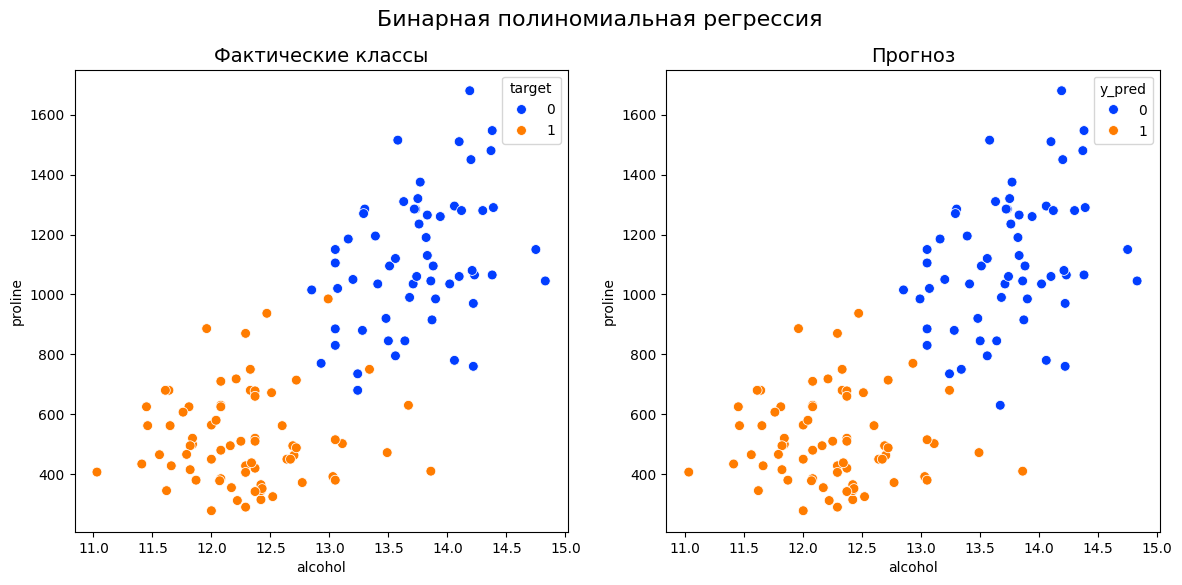

In [ ]:
# создадим два подграфика с помощью функции plt.subplots()
# расположим подграфики на одной строке
fig, (ax1, ax2) = plt.subplots(1, 2,
                               # пропишем размер,
                               figsize = (14, 6),
                               # а также расстояние между подграфиками по горизонтали
                               gridspec_kw = {'wspace' : 0.2})

# на левом подграфике выведем фактические классы
sns.scatterplot(data = df, x = 'alcohol', y = 'proline', hue = 'target', palette = 'bright', s = 50, ax = ax1)
ax1.set_title('Фактические классы', fontsize = 14)

# на правом - прогнозные
sns.scatterplot(data = predictions, x = 'alcohol', y = 'proline', hue = 'y_pred', palette = 'bright', s = 50, ax = ax2)
ax2.set_title('Прогноз', fontsize = 14)

# зададим общий заголовок
fig.suptitle('Бинарная полиномиальная регрессия', fontsize = 16)

plt.show()

Как вы видите, нам не удалось добиться улучшения по сравнению с обычной полиномиальной регрессией.

Напомню, что создание подграфиков мы подробно разобрали на занятии по исследовательскому анализу данных.

В качестве упражнения предлагаю вам выяснить, какая степень полинома позволит улучшить результат прогноза на этих данных и насколько, таким образом, повысится качество предсказаний.

Перейдем ко второй части нашего занятия.

## Мультиклассовая логистическая регрессия
Как поступить, если нужно предсказать не два класса, а больше? Сегодня мы
рассмотрим два подхода: one-vs-rest и кросс-энтропию. Начнем с того, что
подготовим данные.


### Подготовка данных
Вернем исходный датасет с тремя классами.

In [ ]:
# вновь импортируем датасет о вине
data = datasets.load_wine()

# превратим его в датафрейм
df = pd.DataFrame(data.data, columns = data.feature_names)

# приведем признаки к одному масштабу
df = (df - df.mean())/df.std()

# добавим целевую переменную
df['target'] = data.target

# убедимся, что у нас присутствуют все три класса
df.target.value_counts()

,count
target,
1,71
0,59
2,48


В целевой переменной большое двух классов, а значит точечно-бисериальный коэффициент корреляции мы использовать не можем. Воспользуемся корреляционным отношением.

#### Отбор признаков

In [ ]:
# код ниже был подробно разобран на предыдущем занятии
def correlation_ratio(numerical, categorical):

  values = np.array(numerical)
  ss_total = np.sum((values.mean() - values) ** 2)

  cats = np.unique(categorical, return_inverse = True)[1]

  ss_betweengroups = 0

  for c in np.unique(cats):

    group = values[np.argwhere(cats == c).flatten()]
    ss_betweengroups += len(group) * (group.mean() - values.mean()) ** 2

  return np.sqrt(ss_betweengroups/ss_total)

In [ ]:
# создадим два списка, один для названий признаков, второй для значений корреляционного отношения
columns, correlations = [], []

# пройдемся по всем столбцам датафрейма кроме целевой переменной
for col in df.drop('target', axis = 1).columns:
  # поместим название признака в список columns
  columns.append(col)
  # рассчитаем взаимосвязь этого признака с целевой переменной
  # и поместим результат в список значений корреляционного отношения
  correlations.append(correlation_ratio(df[col], df['target']))

# создадим датафрейм на основе заполненных списков
# и применим градиентную цветовую схему
pd.DataFrame({'column': columns, 'correlation': correlations}).style.background_gradient()

,column,correlation
0,alcohol,0.779024
1,malic_acid,0.544857
2,ash,0.363394
3,alcalinity_of_ash,0.538689
4,magnesium,0.352680
5,total_phenols,0.719163
6,flavanoids,0.853098
7,nonflavanoid_phenols,0.489519
8,proanthocyanins,0.506986
9,color_intensity,0.761353


Теперь наибольшую корреляцию с целевой переменной показывают флавоноиды (flavanoids) и пролин (proline). Их и оставим.

In [ ]:
# оставим два признака с наибольшей корреляцией с целевой переменной
df = df[['flavanoids', 'proline', 'target']].copy()
df.head(3)

,flavanoids,proline,target
0,1.031908,1.010159,0
1,0.731565,0.962526,0
2,1.212114,1.391224,0


Посмотрим, насколько легко можно разделить эти классы.

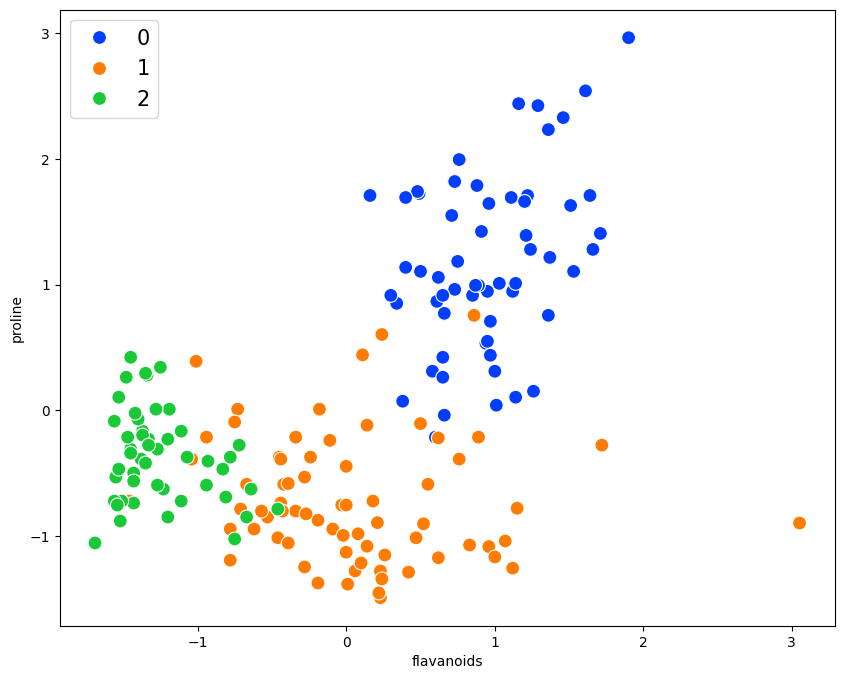

In [ ]:
# зададим размер графика
plt.figure(figsize = (10, 8))
# построим точечную диаграмму с двумя признаками, разделяющей категориальной переменной будет класс вина
sns.scatterplot(x = df.flavanoids, y = df.proline, hue = df.target, palette = 'bright', s = 100)
# добавим легенду
plt.legend(loc = 'upper left', prop = {'size': 15})
plt.show()

Перейдем непосредственно к алгоритмам мультиклассовой логистической
регрессии. Начнем с подхода one-vs-rest.

### Подход one-vs-rest

![](https://drive.google.com/uc?export=view&id=1IRON48JSbohCwEWr19qebXN0FDaA8Dvb)

Подход one-vs-rest или one-vs-all предполагает, что мы отделяем один класс, а остальные наоборот объединяем. Так мы поступаем с каждым классом и строим по одной модели логистической регрессии относительно каждого из классов.
Например, если у нас три класса, то у нас будет три модели логистической
регрессии. Далее мы смотрим на получившиеся вероятности и выбираем
наибольшую.

$$ h_\theta^{(i)}(x) = P(y = i \mid x; \theta), i \in \{0, 1, 2\} $$

При таком подходе сам по себе алгоритм логистической регрессии претерпевает лишь несущественные изменения, главное правильно подготовить данные для обучения модели.

#### Подготовка датасетов

In [ ]:
# поместим признаки и данные в соответствующие переменные
x1, x2 = df.columns[0], df.columns[1]

target = df.target.unique()
target

array([0, 1, 2])

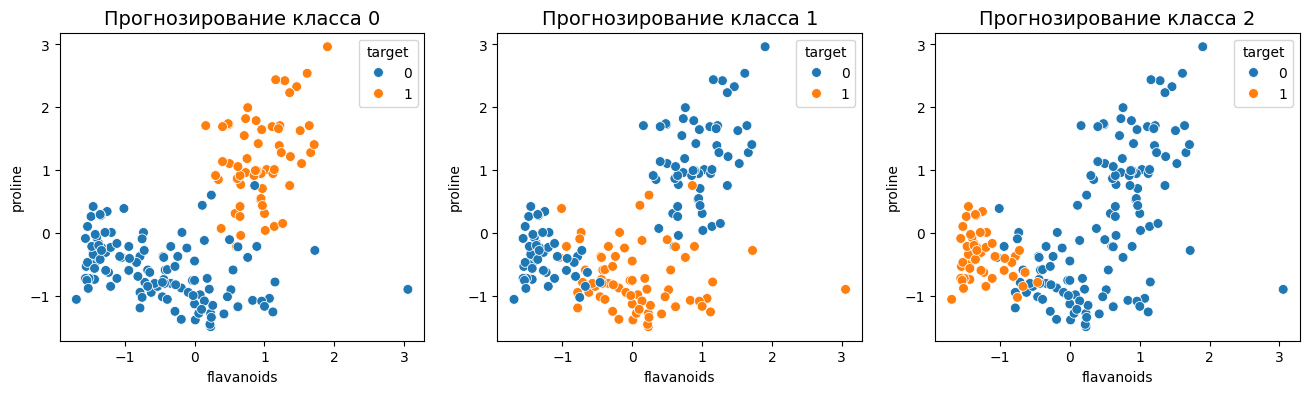

In [ ]:
# сделаем копии датафреймов
ovr_0, ovr_1, ovr_2 = df.copy(), df.copy(), df.copy()

# в каждом из них сделаем целевым классом 0-й, 1-й или 2-й классы
# например, в ovr_0 первым классом будет класс 0, а классы 1 и 2 - нулевым
ovr_0['target'] = np.where(df['target'] == target[0], 1, 0)
ovr_1['target'] = np.where(df['target'] == target[1], 1, 0)
ovr_2['target'] = np.where(df['target'] == target[2], 1, 0)

# выведем разделение на классы на графике
fig, (ax1, ax2, ax3) = plt.subplots(1, 3,
                                    figsize = (16, 4),
                                    gridspec_kw = {'wspace': 0.2, 'hspace': 0.08})

sns.scatterplot(data = ovr_0, x = x1, y = x2, hue = 'target', s = 50, ax = ax1)
ax1.set_title('Прогнозирование класса 0', fontsize = 14)

sns.scatterplot(data = ovr_1, x = x1, y = x2, hue = 'target', s = 50, ax = ax2)
ax2.set_title('Прогнозирование класса 1', fontsize = 14)

sns.scatterplot(data = ovr_2, x = x1, y = x2, hue = 'target', s = 50, ax = ax3)
ax3.set_title('Прогнозирование класса 2', fontsize = 14)

plt.show()

In [ ]:
ovr_0.head(3)

,flavanoids,proline,target
0,1.031908,1.010159,1
1,0.731565,0.962526,1
2,1.212114,1.391224,1


#### Обучение моделей

In [ ]:
models = []

# поочередно обучим каждую из моделей
for ova_n in [ovr_0, ovr_1, ovr_2]:
  X = ova_n[['flavanoids', 'proline']]
  y = ova_n['target']

  model = LogReg()
  model.fit(X, y)

  # каждую обученную модель поместим в список
  models.append(model)

In [ ]:
# убедимся, что все работает
# например, выведем коэффициенты модели 1
models[0].thetas

array([-0.99971466,  1.280398  ,  2.04834457])

#### Прогноз и оценка качества

In [ ]:
# вновь перенесем данные из исходного датафрейма
X = df[['flavanoids', 'proline']]
y = df['target']

# в список probs будем записывать результат каждой модели
# т.е. три массива Numpy по 178 вероятностей
probs = []

for model in models:
  _, prob = model.predict(X)
  probs.append(prob)

In [ ]:
# очевидно, для каждого наблюдения у нас будет три вероятности
# принадлежности к целевому классу
probs[0][0], probs[1][0], probs[2][0]

(np.float64(0.9161148288779739),
 np.float64(0.15409133953450904),
 np.float64(0.02662113260010316))

In [ ]:
# склеим внутренние и изменим размерность массива таким образом, чтобы
# строки были наблюдениями, а столбцы вероятностями
all_probs = np.concatenate(probs, axis = 0).reshape(len(probs), -1).T
all_probs.shape

(178, 3)

In [ ]:
# каждая из 178 строк - это вероятность одного наблюдения принадлежать к классу 0, 1, 2
all_probs[0]

array([0.91611483, 0.15409134, 0.02662113])

Обратите внимание, при использовании подхода one-vs-rest вероятности в сумме не дают единицу.

In [ ]:
# например, первое наблюдение вероятнее всего принадлежит к классу 0
np.argmax(all_probs[0])

np.int64(0)

In [ ]:
# найдем максимальную вероятность в каждой строке,
# индекс вероятности [0, 1, 2] и будет прогнозом
y_pred = np.argmax(all_probs, axis = 1)

# рассчитаем accuracy
accuracy_score(y, y_pred)

0.9157303370786517

In [ ]:
# выведем матрицу ошибок
pd.DataFrame(confusion_matrix(y, y_pred),
             columns = ['Forecast 0', 'Forecast 1', 'Forecast 2'],
             index = ['Actual 0', 'Actual 1', 'Actual 2'])

,Forecast 0,Forecast 1,Forecast 2
Actual 0,57,2,0
Actual 1,3,62,6
Actual 2,0,4,44


Сравним фактическое и прогнозное распределение классов на точечной диаграмме.

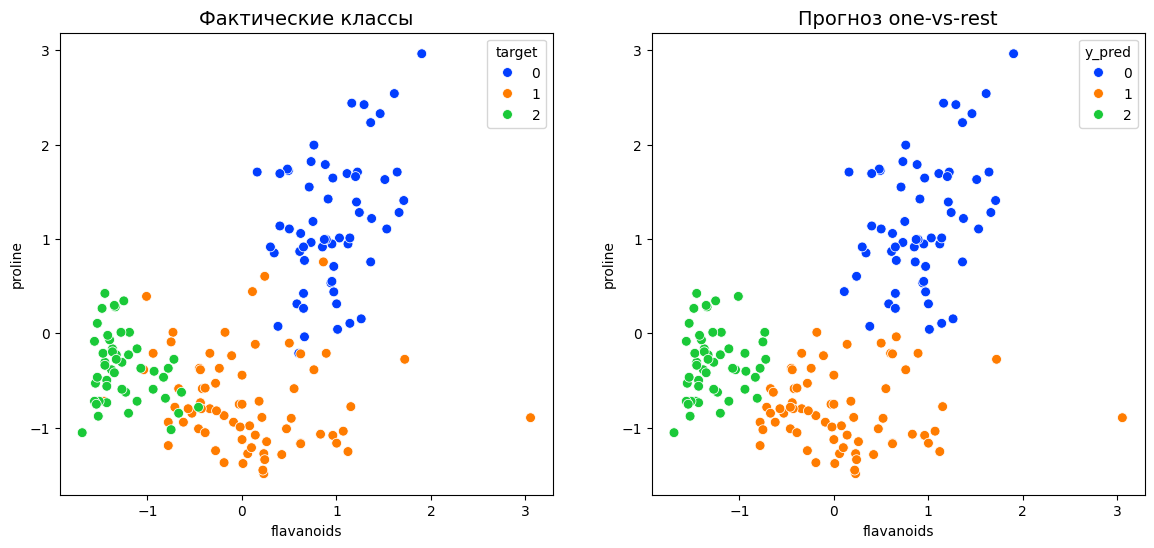

In [ ]:
predictions = df[['flavanoids', 'proline']].copy()
predictions['y_pred'] = y_pred

fig, (ax1, ax2) = plt.subplots(1, 2,
                               figsize = (14, 6),
                               gridspec_kw = {'wspace': 0.2, 'hspace': 0.08})

sns.scatterplot(data = df, x = 'flavanoids', y = 'proline', hue = 'target',
                palette = 'bright', s = 50, ax = ax1)

ax1.set_title('Фактические классы', fontsize = 14)

sns.scatterplot(data = predictions, x = 'flavanoids', y = 'proline', hue = 'y_pred',
                palette = 'bright', s = 50, ax = ax2)

ax2.set_title('Прогноз one-vs-rest', fontsize = 14)

plt.show()

#### Написание класса
Поместим написанный выше код в класс.

In [ ]:
class OVR_LogReg():

  def __init__(self):
    self.models_thetas = []
    self.models_loss = []

  def fit(self, x, y, iter = 20000, learning_rate = 0.001):

    dfs = self.preprocess(x, y)

    models_thetas, models_loss = [], []

    for ovr_df in dfs:

      x = ovr_df.drop('target', axis = 1).copy()
      y = ovr_df.target.copy()

      self.add_ones(x)

      loss_history = []
      thetas, n = np.zeros(x.shape[1]), x.shape[0]

      for i in range(iter):
        y_pred = self.h(x, thetas)
        loss_history.append(self.objective(y, y_pred))
        grad = self.gradient(x, y, y_pred, n)
        thetas -= learning_rate * grad

      models_thetas.append(thetas)
      models_loss.append(loss_history)

    self.models_thetas = models_thetas
    self.models_loss = models_loss

  def predict(self, x):
    x = x.copy()
    probs = []
    self.add_ones(x)
    for t in self.models_thetas:
      z = np.dot(x, t)
      prob = np.array([self.stable_sigmoid(value) for value in z])
      probs.append(prob)

    all_probs = np.concatenate(probs, axis = 0).reshape(len(probs), -1).T
    y_pred = np.argmax(all_probs, axis = 1)

    return y_pred, all_probs

  def preprocess(self, x, y):

    x, y = x.copy(), y.copy()

    x['target'] = y
    classes = x.target.unique()

    dfs = []
    ovr_df = None

    for c in classes:
      ovr_df = x.drop('target', axis = 1).copy()
      ovr_df['target'] = np.where(x['target'] == classes[c], 1, 0)
      dfs.append(ovr_df)

    return dfs

  def add_ones(self, x):
    return x.insert(0,'x0', np.ones(x.shape[0]))

  def h(self, x, thetas):
    z = np.dot(x, thetas)
    return np.array([self.stable_sigmoid(value) for value in z])

  def objective(self, y, y_pred):
    y_one_loss = y * np.log(y_pred + 1e-9)
    y_zero_loss = (1 - y) * np.log(1 - y_pred + 1e-9)
    return -np.mean(y_zero_loss + y_one_loss)

  def gradient(self, x, y, y_pred, n):
    return np.dot(x.T, (y_pred - y)) / n

  def stable_sigmoid(self, z):
    if z >= 0:
        return 1 / (1 + np.exp(-z))
    else:
        return np.exp(z) / (np.exp(z) + 1)

Проверим класс в работе.

In [ ]:
X = df[['flavanoids', 'proline']]
y = df['target']

model = OVR_LogReg()
model.fit(X, y)

y_pred, probs = model.predict(X)
accuracy_score(y_pred, y)

0.9157303370786517

#### Сравнение с sklearn

Для того чтобы применить подход one-vs-rest в классе LogisticRegression,
необходимо использовать OneVsRestClassifier.

In [ ]:
from sklearn.multiclass import OneVsRestClassifier

X = df[['flavanoids', 'proline']]
y = df['target']

ovr_model = OneVsRestClassifier(LogisticRegression())
ovr_model = ovr_model.fit(X, y)
y_pred = ovr_model.predict(X)

accuracy_score(y_pred, y)

0.898876404494382

### Полиномиальная мультиклассовая регрессия
Как мы увидели в предыдущем разделе, линейная решающая граница допустила
некоторое количество ошибок. Попробуем улучшить результат, применив
мультиклассовую полиномиальную логистическую регрессию.

In [ ]:
X = df[['flavanoids', 'proline']]
y = df['target']

polynomial_features = PolynomialFeatures(degree = 7)

X_poly = polynomial_features.fit_transform(X)

poly_ovr_model = OneVsRestClassifier(LogisticRegression())
poly_ovr_model = poly_ovr_model.fit(X_poly, y)
y_pred = poly_ovr_model.predict(X_poly)

accuracy_score(y_pred, y)

0.9157303370786517

Результат, по сравнению с моделью sklearn без полиномиальных признаков, стал чуть лучше. Однако это было достигнуто за счет полинома достаточно высокой степени (degree = 7), что может быть неэффективно с точки зрения временной сложности алгоритма.

Посмотрим, какие нелинейные решающие границы удалось построить алгоритму.

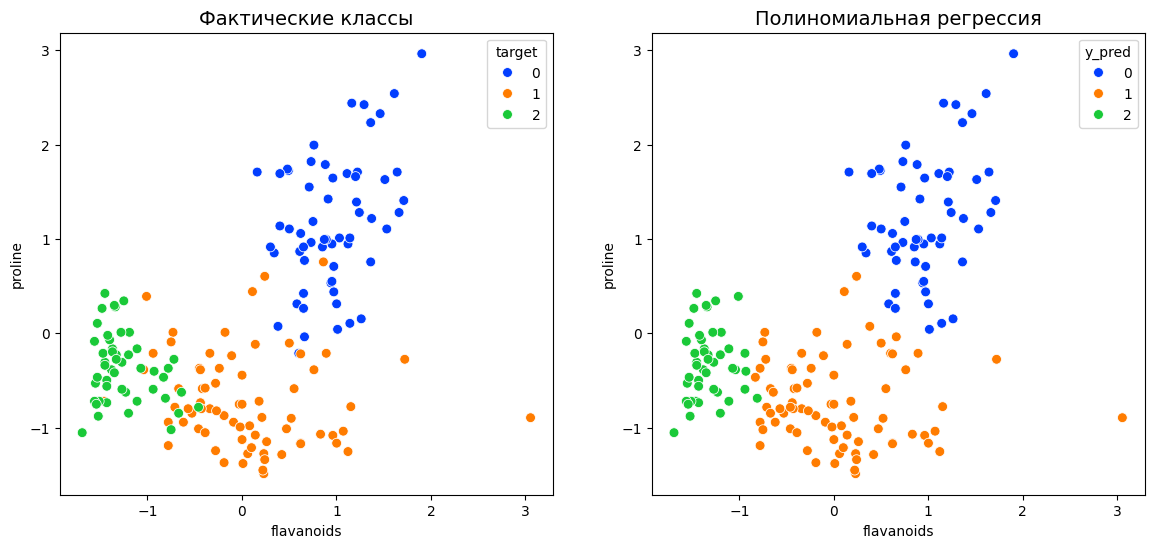

In [ ]:
predictions = df[['flavanoids', 'proline']].copy()
predictions['y_pred'] = y_pred

fig, (ax1, ax2) = plt.subplots(1, 2,
                               figsize = (14, 6),
                               gridspec_kw = {'wspace': 0.2, 'hspace': 0.08})

sns.scatterplot(data = df, x = 'flavanoids', y = 'proline', hue = 'target', palette = 'bright', s = 50, ax = ax1)
ax1.set_title('Фактические классы', fontsize = 14)

sns.scatterplot(data = predictions, x = 'flavanoids', y = 'proline', hue = 'y_pred', palette = 'bright', s = 50, ax = ax2)
ax2.set_title('Полиномиальная регрессия', fontsize = 14)

plt.show()

### Softmax Regression

Еще один подход при создании мультиклассовой логистической регрессии
заключается в том, чтобы не разбивать многоклассовые данные на несколько датасетов и использовать бинарный классификатор, а сразу применять функции, которые подходят для работы с множеством классов.

Такую регрессию часто называют Softmax Regression из-за того, что в ней используется уже знакомая нам по занятию об основах нейросетей функция softmax. Вначале подготовим данные.

#### Подготовка признаков
Возьмем признаки flavanoids и proline и добавим столбец из единиц.

In [ ]:
def add_ones(x):
  # важно! метод .insert() изменяет исходный датафрейм
  return x.insert(0,'x0', np.ones(x.shape[0]))

In [ ]:
X = df[['flavanoids', 'proline']]

add_ones(X)
X.head(3)

,x0,flavanoids,proline
0,1.0,1.031908,1.010159
1,1.0,0.731565,0.962526
2,1.0,1.212114,1.391224


#### Кодирование целевой переменной
Напишем собственную функцию для one-hot encoding.

In [ ]:
def ohe(y):
  # количество примеров и количество классов
  examples, features = y.shape[0], len(np.unique(y))
  # нулевая матрица: количество наблюдений x количество признаков
  zeros_matrix = np.zeros((examples, features))
  # построчно проходимся по нулевой матрице и с помощью индекса заполняем соответствующее значение единицей
  for i, (row, digit) in enumerate(zip(zeros_matrix, y)):
    zeros_matrix[i][digit] = 1

  return zeros_matrix

In [ ]:
y = df['target']

y_enc = ohe(df['target'])
y_enc[:3]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

Такой же результат можно получить с помощью класса LabelBinarizer.

In [ ]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
lb.fit(y)
lb.classes_

array([0, 1, 2])

In [ ]:
y_lb = lb.transform(y)
y_lb[:5]

array([[1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0]])

#### Инициализация весов
Создадим нулевую матрицу весов. Она будет иметь размерность: количество
признаков (строки) х количество классов (столбцы). Приведем схематичный
пример для четырех наблюдений, трех признаков (включая сдвиг $\theta_0$) и трех
классов.
![](https://drive.google.com/uc?export=view&id=1uqUw7UDfpNU6kpHMe5NkukwlXRpeKurE)


Инициализируем веса.

In [ ]:
# размерность матрицы весов:
# количество признаков х количество классов
thetas = np.zeros((3, 3))
thetas

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

#### Функция softmax
Подробнее изучим функцию softmax. Приведем формулу.

$$ \text{softmax}(z_{i}) = \frac{e^{z_i}}{\sum_{k=1}^N e^{z_k}} $$

Рассмотрим ее реализацию на Питоне.

Напомню, что $ z = (-X\theta) $. Соответственно в нашем случае мы будем умножать матрицу 178 x 3 на 3 x 3.

In [ ]:
X.shape, thetas.shape

((178, 3), (3, 3))

В результате получим матрицу 178 x 3, где каждая строка — это прогнозные
значения принадлежности одного наблюдения к каждому из трех классов.

In [ ]:
z = np.dot(-X, thetas)
z.shape

(178, 3)

Так как мы умножаем на ноль, при первой итерации эти значения будут равны
нулю.

In [ ]:
z[:5]

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

Для того чтобы обеспечить вычислительную устойчивость softmax, мы можем
вычесть из $z$ максимальное значение в каждой из 178 строк (пока что, опять же на
первой итерации, оно равно нулю).

$$ \text{softmax}(z)_{i} = \frac{e^{z_i-max(z)}}{\sum_{k=1}^N e^{z_k-max(z)}} $$

In [ ]:
# axis = -1 - это последняя ось
# keepdims = True сохраняет размерность (в данном случае двумерный массив)
np.max(z, axis = -1, keepdims = True)[:5]

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [ ]:
z = z - np.max(z, axis = -1, keepdims = True)
z[:5]

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

Смысл такого преобразования в том, что оно делает значения $z$ нулевыми или отрицательными.

In [ ]:
arr = np.array([-2, 3, 0, -7, 6])
arr - max(arr)

array([ -8,  -3,  -6, -13,   0])

Как следствие, число, возводимое в увеличивающуюся отрицательную степень,
стремится к нулю, а не к бесконечности и, таким образом, не вызывает
переполнения памяти. Найдем числитель и знаменатель из формулы softmax.

In [ ]:
numerator = np.exp(z)
numerator[:5]

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [ ]:
denominator = np.sum(numerator, axis = -1, keepdims = True)
denominator[:5]

array([[3.],
       [3.],
       [3.],
       [3.],
       [3.]])

Разделим числитель и знаменатель и, таким образом, вычислим вероятность
принадлежности каждого из наблюдений (строки результата) к одному из трех
классов (столбцы).

In [ ]:
softmax = numerator / denominator
softmax[:5]

array([[0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333]])

На первой итерации при одинаковых $\theta$ мы получаем, что логично,
одинаковые вероятности принадлежности к каждому из классов. Напишем
функцию.

In [ ]:
def stable_softmax(x, thetas):
  z = np.dot(-x, thetas)
  z = z - np.max(z, axis = -1, keepdims = True)
  numerator = np.exp(z)
  denominator = np.sum(numerator, axis = -1, keepdims = True)
  softmax = numerator / denominator
  return softmax

In [ ]:
probs = stable_softmax(X, thetas)
probs[:3]

array([[0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333]])

***Примечание.*** Обратите внимание, что сигмоида — это частный случай функции
softmax для двух классов $[z_1, 0]$. Вероятность класса $z_1$ будет равна

$$ softmax(z_1) = \frac{e^{z_1}}{e^{z_1}+e^0} = \frac{e^{z_1}}{e^{z_1}+1} $$

Если разделить и числитель, и знаменатель на $e^{z_1}$, то получим

$$ sigmoid(z_1) = \frac{e^{z_1}}{1 + e^{-z_1}} $$

Вычислять вероятность принадлежности ко второму классу нет необходимости, достаточно вычесть результат сигмоиды из единицы.

Теперь нужно понять, насколько сильно при таких весах ошибается наш алгоритм.

#### Функция потерь

Вспомним функцию бинарной кросс-энтропии. То есть функции ошибки для двух
классов.

$$ L(y, \theta) = -\frac{1}{n} \sum y \cdot log(h_{\theta}(x)) + (1-y) \cdot log(1-
h_{\theta}(x)) $$

Напомню, что $y$ выступает в роли своего рода переключателя, сохраняющего
одну из частей выражения, и обнуляющего другую. Теперь посмотрите на функцию
категориальной (многоклассовой) кросс-энтропии (categorical cross-entropy).

$$ L(y_{ohe}, softmax) = -\sum y_{ohe} \cdot log(softmax) $$

Разберемся, что здесь происходит. В $y_{ohe}$ содержится закодированная целевая
переменная, например, для наблюдения класса 0 это [1, 0, 0]. Одновременно softmax
содержит вектор вероятностей принадлежности наблюдения к каждому из классов,
например, [0,3 0,4 0,3] (мы видим, что алгоритм ошибается).

В данном случае закодированная целевая переменная также выступает в виде
переключателя. Здесь при умножении «срабатывает» только первая вероятность

$$1 \times 0{,}3 + 0 \times 0{,}4 + 0 \times 0{,}3 $$

Если подставить в формулу, то получаем

In [ ]:
y_ohe = np.array([1, 0, 0])
softmax = np.array([0.3, 0.4, 0.3])

-np.sum(y_ohe * np.log(softmax))

np.float64(1.2039728043259361)

Если бы модель в своих вероятностях ошибалась меньше, то и общая ошибка была
бы меньше.

In [ ]:
y_ohe = np.array([1, 0, 0])
softmax = np.array([0.4, 0.3, 0.3])

-np.sum(y_ohe * np.log(softmax))

np.float64(0.916290731874155)

Функция $-\log$ позволяет снижать ошибку при увеличении вероятности верного
(сохраненного переключателем) класса.

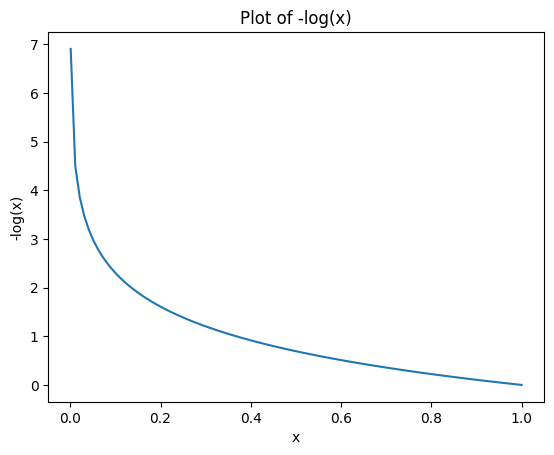

In [ ]:
x_arr = np.linspace(0.001,1, 100)
sns.lineplot(x=x_arr,y=-np.log(x_arr))
plt.title('Plot of -log(x)')
plt.xlabel('x')
plt.ylabel('-log(x)');

Напишем функцию.

In [ ]:
# добавим константу в логарифм для вычислительной устойчивости
def cross_entropy(probs, y_enc, epsilon = 1e-9):
  n = probs.shape[0]
  ce = -np.sum(y_enc * np.log(probs + epsilon)) / n
  return ce

Рассчитаем ошибку для нулевых весов.

In [ ]:
ce = cross_entropy(probs, y_enc)
ce

np.float64(1.0986122856681098)

Для снижения ошибки нужно найти градиент.

#### Градиент
Приведем формулу градиента без дифференцирования.

$$ \nabla_{\theta}J = X^\top (y_{ohe}-softmax) \times \frac{1}{n} $$

По сути, мы умножаем транспонированную матрицу признаков (3 x 178) на разницу между закодированной целевой переменной и вероятностями функции softmax (178 x 3).

In [ ]:
def gradient_softmax(X, probs, y_enc):
  return np.array(np.dot(X.T, (y_enc - probs)) * (1 / probs.shape[0]))

In [ ]:
gradient_softmax(X, probs, y_enc)

array([[-0.00187266,  0.06554307, -0.06367041],
       [ 0.31627721,  0.02059572, -0.33687293],
       [ 0.38820566, -0.28801792, -0.10018774]])

#### Обучение модели, прогноз и оценка качества
Выполним обучение модели.

In [ ]:
loss_history = []

# в цикле
for i in range(30000):
  # рассчитаем прогнозное значение с текущими весами
  probs = stable_softmax(X, thetas)
  # посчитаем уровень ошибки при текущем прогнозе
  loss_history.append(cross_entropy(probs, y_enc, epsilon = 1e-9))
  # рассчитаем градиент
  grad = gradient_softmax(X, probs, y_enc)
  # используем градиент для улучшения весов модели
  thetas = thetas - 0.002 * grad

Посмотрим на получившиеся коэффициенты (напомню, что первая строка матрицы
это сдвиг (intercept, $\theta_0$)) и достигнутый уровень ошибки.

In [ ]:
thetas

array([[ 0.11290134, -0.90399727,  0.79109593],
       [-1.7550965 , -0.7857371 ,  2.5408336 ],
       [-1.93839311,  1.77140542,  0.16698769]])

In [ ]:
loss_history[0], loss_history[-1]

(np.float64(1.0986122856681098), np.float64(0.2569641080523888))

Сделаем прогноз и оценим качество.

In [ ]:
y_pred = np.argmax(stable_softmax(X, thetas), axis = 1)

In [ ]:
accuracy_score(y, y_pred)

0.9044943820224719

In [ ]:
pd.DataFrame(confusion_matrix(y, y_pred),
             columns = ['Forecast 0', 'Forecast 1', 'Forecast 2'],
             index = ['Actual 0', 'Actual 1', 'Actual 2'])

,Forecast 0,Forecast 1,Forecast 2
Actual 0,56,3,0
Actual 1,3,62,6
Actual 2,0,5,43


#### Написание класса

Объединим созданные выше компоненты в класс.

In [ ]:
class SoftmaxLogReg():

  def __init__(self):
    self.loss_ = None
    self.thetas_ = None

  def fit(self, x, y, iter = 30000, learning_rate = 0.002):

    loss_history = []

    self.add_ones(x)
    y_enc = self.ohe(y)
    thetas = np.zeros((x.shape[1], y_enc.shape[1]))

    for i in range(iter):
      probs = self.stable_softmax(x, thetas)
      loss_history.append(self.cross_entropy(probs, y_enc, epsilon = 1e-9))
      grad = self.gradient_softmax(x, probs, y_enc)
      thetas = thetas - 0.002 * grad

      self.thetas_ = thetas
      self.loss_ = loss_history

  def predict(self, x, y):
    return np.argmax(self.stable_softmax(x, thetas), axis = 1)

  def stable_softmax(self, x, thetas):
    z = np.dot(-x, thetas)
    z = z - np.max(z, axis = -1, keepdims = True)
    numerator = np.exp(z)
    denominator = np.sum(numerator, axis = -1, keepdims = True)
    softmax = numerator / denominator
    return softmax

  def cross_entropy(self, probs, y_enc, epsilon = 1e-9):
    n = probs.shape[0]
    ce = -np.sum(y_enc * np.log(probs + epsilon)) / n
    return ce

  def gradient_softmax(self, x, probs, y_enc):
    return np.array(1 / probs.shape[0] * np.dot(x.T, (y_enc - probs)))

  def add_ones(self, x):
    return x.insert(0,'x0', np.ones(x.shape[0]))

  def ohe(self, y):
    examples, features = y.shape[0], len(np.unique(y))
    zeros_matrix = np.zeros((examples, features))
    for i, (row, digit) in enumerate(zip(zeros_matrix, y)):
      zeros_matrix[i][digit] = 1

    return zeros_matrix

Обучим модель, сделаем прогноз и оценим качество.

In [ ]:
X = df[['flavanoids', 'proline']]
y = df['target']

model = SoftmaxLogReg()

model.fit(X, y)
model.thetas_, model.loss_[-1]

(array([[ 0.11290134, -0.90399727,  0.79109593],
        [-1.7550965 , -0.7857371 ,  2.5408336 ],
        [-1.93839311,  1.77140542,  0.16698769]]),
 np.float64(0.2569641080523888))

In [ ]:
y_pred = model.predict(X, y)

accuracy_score(y, y_pred)

0.9044943820224719

#### Сравнение с sklearn

В sklearn softmax логистическая регрессия используется по умолчанию при наличии более двух классов целевой переменной.



In [ ]:
X = df[['flavanoids', 'proline']]
y = df['target']

# создадим объект класса LogisticRegression и запишем его в переменную model
model = LogisticRegression()

# обучим нашу модель
model.fit(X, y)

# посмотрим на получившиеся веса модели
model.intercept_, model.coef_

(array([ 0.09187961,  1.12589881, -1.21777842]),
 array([[ 1.86262022,  1.89660649],
        [ 0.86759485, -1.43893599],
        [-2.73021507, -0.4576705 ]]))

In [ ]:
y_pred = model.predict(X)

accuracy_score(y, y_pred)

0.898876404494382

Обобщим сказанное
Сегодня мы разобрали множество разновидностей и подходов к использованию
логистической регрессии. Систематизируем изученный материал:
* в случае если у нас объекты двух классов, речь идет о бинарной регрессии;
* если же классов больше двух, существует два подхода:
  * one-vs-rest;
  * softmax regression.
  
При этом каждая модель допускает использование как линейных, так и
полиномиальных признаков.